In [2]:
%pip install -q torch torchvision astropy numpy pandas matplotlib scipy

Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip list

Package                   Version
------------------------- --------------------
annotated-types           0.8.0
anyio                     4.14.2
argon2-cffi               25.1.0
argon2-cffi-bindings      26.1.0
arrow                     1.4.0
astropy                   8.0.1
astropy-iers-data         0.2026.8.18.14.22.31
asttokens                 3.0.2
async-lru                 2.3.0
attrs                     26.1.0
babel                     2.18.0
beautifulsoup4            4.15.0
bleach                    6.4.0
certifi                   2026.7.22
cffi                      2.1.1
charset-normalizer        3.5.1
click                     8.4.2
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.3
cycler                    0.12.1
debugpy                   1.8.21
defusedxml                0.7.1
einops                    0.8.2
executing                 2.2.1
fastjsonschema            2.22.2
filelock                  3.32.3
fonttools                 

In [7]:
# Import all packages required by this notebook
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from astropy.io import fits
from astropy.wcs import WCS
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.wcs import utils as wcs_utils

from scipy.interpolate import interpn
from scipy.optimize import linear_sum_assignment


In [8]:
# Find the project root directory
PROJECT_ROOT = Path.cwd()

# Move to the project root if the notebook is inside the notebooks directory
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Define data directories
RAW_DIR = PROJECT_ROOT / "data" / "raw"
CATALOG_DIR = PROJECT_ROOT / "data" / "catalog"

# Define output directory
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "yolo_cianna"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: d:\AST\03_YOLO_Radio_Astronomy


In [10]:
from urllib.request import urlretrieve

# Define YOLO-CIANNA SDC1 input files
image_path = RAW_DIR / "SKAMid_B1_1000h_v3.fits"
beam_path = RAW_DIR / "PrimaryBeam_B1.fits"
training_catalog_path = CATALOG_DIR / "TrainingSet_B1_v2.txt"

# Official download URLs
download_urls = {
    image_path:
        "https://owncloud.ia2.inaf.it/index.php/s/hbasFhd4YILNkCr/download",

    beam_path:
        "https://owncloud.ia2.inaf.it/index.php/s/ZbaSDe7zGBYgxL1/download",

    training_catalog_path:
        "https://owncloud.ia2.inaf.it/index.php/s/iTOVkIL6EfXkcdR/download",
}

# Download only missing files
for file_path, url in download_urls.items():

    file_path.parent.mkdir(parents=True, exist_ok=True)

    if file_path.exists():
        print("Already exists:", file_path.name)
        continue

    print("Downloading:", file_path.name)

    urlretrieve(url, file_path)

    print("Finished:", file_path.name)

Already exists: SKAMid_B1_1000h_v3.fits
Already exists: PrimaryBeam_B1.fits
Downloading: TrainingSet_B1_v2.txt
Finished: TrainingSet_B1_v2.txt


In [15]:
# Keep the large FITS image memory-mapped
image_hdul = fits.open(
    image_path,
    memmap=True
)

full_image = np.squeeze(
    image_hdul[0].data
)

image_wcs = WCS(
    image_hdul[0].header
).celestial

# Load the much smaller primary-beam image into memory
with fits.open(beam_path) as beam_hdul:
    beam_image = np.squeeze(
        beam_hdul[0].data
    ).astype(np.float32)

    beam_wcs = WCS(
        beam_hdul[0].header
    ).celestial

# Define catalogue columns
catalog_columns = [
    "ID",
    "RA_core",
    "DEC_core",
    "RA_centroid",
    "DEC_centroid",
    "FLUX",
    "Core_frac",
    "BMAJ",
    "BMIN",
    "PA",
    "SIZE",
    "CLASS",
    "SELECTION",
    "x",
    "y",
]

# Load the official B1 training catalogue
catalog = pd.read_csv(
    training_catalog_path,
    sep=r"\s+",
    skiprows=18,
    names=catalog_columns
)

print("Image shape:", full_image.shape)
print("Primary beam shape:", beam_image.shape)
print("Catalogue sources:", len(catalog))

catalog.head()

Image shape: (32768, 32768)
Primary beam shape: (257, 257)
Catalogue sources: 274883


,ID,RA_core,DEC_core,RA_centroid,DEC_centroid,FLUX,Core_frac,BMAJ,BMIN,PA,SIZE,CLASS,SELECTION,x,y
0,19583869,-0.027182,-29.880180,-0.025817,-29.881346,3.071800e-05,0.007015,242.875,124.447,19.617,1,1,1,16516.367,17089.901
1,2200269,-0.311221,-29.578638,-0.311221,-29.578638,3.354310e-08,-0.000000,255.579,85.189,25.461,1,1,1,17995.551,18891.185
2,20370953,-0.156639,-29.613901,-0.156022,-29.610902,5.051040e-08,0.013133,157.013,135.343,15.008,1,1,1,17191.154,18700.606
3,3922693,-0.568954,-29.680477,-0.567827,-29.677515,7.818010e-08,0.000487,66.171,57.413,270.983,1,1,1,19322.199,18297.016
4,22627893,-0.100985,-29.692011,-0.100985,-29.692011,3.785790e-08,-0.000000,346.540,180.875,310.391,1,1,1,16905.655,18217.704


In [16]:
# Start from catalogue sources selected by the official SDC1 catalogue
selected_catalog = catalog[
    catalog["SELECTION"] == 1
].copy()

print(
    "Sources after SELECTION filter:",
    len(selected_catalog)
)

# Convert source sky coordinates into primary-beam pixels
source_sky = SkyCoord(
    ra=selected_catalog["RA_core"].to_numpy() * u.degree,
    dec=selected_catalog["DEC_core"].to_numpy() * u.degree,
    frame="icrs"
)

beam_x, beam_y = wcs_utils.skycoord_to_pixel(
    source_sky,
    beam_wcs
)

# Sample the primary beam at each source position
beam_values = interpn(
    (
        np.arange(beam_image.shape[0]),
        np.arange(beam_image.shape[1]),
    ),
    np.nan_to_num(beam_image),
    (
        beam_y,
        beam_x,
    ),
    method="splinef2d",
    bounds_error=False,
    fill_value=0.0
)

# Calculate apparent flux
apparent_flux = (
    selected_catalog["FLUX"].to_numpy()
    * beam_values
)

# Use the same pixel scale as the reference implementation
pixel_size_deg = 0.000167847

# Convert major and minor axes into approximate pixel dimensions
major_pixels = (
    np.clip(
        selected_catalog["BMAJ"].to_numpy(),
        1.2,
        None
    )
    /
    (3600.0 * pixel_size_deg)
    * 2.0
)

minor_pixels = (
    np.clip(
        selected_catalog["BMIN"].to_numpy(),
        0.6,
        None
    )
    /
    (3600.0 * pixel_size_deg)
    * 2.0
)

source_surface = (
    major_pixels
    * minor_pixels
)

# Apply the YOLO-CIANNA source-selection conditions
selection_mask = (
    (
        (apparent_flux / source_surface > 1.0e-7)
        &
        (apparent_flux >= 7.0e-6)
    )
    |
    (
        (apparent_flux / source_surface > 2.5e-7)
        &
        (apparent_flux > 1.65e-6)
        &
        (apparent_flux < 7.0e-6)
    )
)

train_catalog = selected_catalog[
    selection_mask
].copy()

train_catalog["apparent_flux"] = (
    apparent_flux[selection_mask]
)

train_catalog = train_catalog.reset_index(
    drop=True
)

print(
    "Final YOLO-CIANNA training sources:",
    len(train_catalog)
)

Sources after SELECTION filter: 190553
Final YOLO-CIANNA training sources: 33813


In [12]:
# Convert source sky coordinates into image pixels
train_sky = SkyCoord(
    ra=train_catalog["RA_core"].to_numpy() * u.degree,
    dec=train_catalog["DEC_core"].to_numpy() * u.degree,
    frame="icrs"
)

source_x, source_y = wcs_utils.skycoord_to_pixel(
    train_sky,
    image_wcs
)

# Calculate source dimensions in pixels
source_width = (
    train_catalog["BMAJ"].to_numpy()
    /
    (3600.0 * pixel_size_deg)
    * 2.0
)

source_height = (
    train_catalog["BMIN"].to_numpy()
    /
    (3600.0 * pixel_size_deg)
    * 2.0
)

position_angle = np.deg2rad(
    train_catalog["PA"].to_numpy()
)

rotated_width = (
    np.abs(
        source_width
        * np.cos(position_angle)
    )
    +
    np.abs(
        source_height
        * np.sin(position_angle)
    )
)

rotated_height = (
    np.abs(
        source_width
        * np.sin(position_angle)
    )
    +
    np.abs(
        source_height
        * np.cos(position_angle)
    )
)

# Apply the same bounding-box size limits as YOLO-CIANNA
rotated_width = np.clip(
    rotated_width,
    5.0,
    64.0
)

rotated_height = np.clip(
    rotated_height,
    5.0,
    64.0
)

# Store source positions and bounding-box dimensions
train_catalog["pixel_x"] = source_x
train_catalog["pixel_y"] = source_y

train_catalog["box_width"] = rotated_width
train_catalog["box_height"] = rotated_height

train_catalog[
    [
        "ID",
        "pixel_x",
        "pixel_y",
        "box_width",
        "box_height",
        "FLUX",
    ]
].head()

,ID,pixel_x,pixel_y,box_width,box_height,FLUX
0,20167150,18400.341545,17169.030544,64.000000,64.000000,0.029555
1,20045120,16493.849598,18507.032430,13.502820,17.900260,0.000653
2,33938384,18020.298829,18182.106921,5.000000,5.000000,0.000017
3,7527248,18125.810865,18600.709024,6.684756,11.713519,0.000054
4,25169187,19349.527085,17789.561298,5.000000,5.000000,0.001505


In [13]:
# Determine the training-region sky boundaries
min_ra = train_catalog["RA_core"].min()
max_ra = train_catalog["RA_core"].max()

min_dec = train_catalog["DEC_core"].min()
max_dec = train_catalog["DEC_core"].max()

# Convert training-region boundaries to image pixels
corner_min = SkyCoord(
    ra=max_ra * u.degree,
    dec=min_dec * u.degree,
    frame="icrs"
)

corner_max = SkyCoord(
    ra=min_ra * u.degree,
    dec=max_dec * u.degree,
    frame="icrs"
)

train_x_min, train_y_min = (
    wcs_utils.skycoord_to_pixel(
        corner_min,
        image_wcs
    )
)

train_x_max, train_y_max = (
    wcs_utils.skycoord_to_pixel(
        corner_max,
        image_wcs
    )
)

# Convert to integer pixel boundaries
train_x_min = int(train_x_min) + 10
train_x_max = int(train_x_max) - 10

train_y_min = int(train_y_min) + 10
train_y_max = int(train_y_max) - 10

training_width = (
    train_x_max - train_x_min
)

training_height = (
    train_y_max - train_y_min
)

print("Training region:")
print(
    "X:",
    train_x_min,
    "to",
    train_x_max
)

print(
    "Y:",
    train_y_min,
    "to",
    train_y_max
)

print(
    "Size:",
    training_width,
    "x",
    training_height
)

Training region:
X: 16393 to 19862
Y: 16750 to 19900
Size: 3469 x 3150


In [14]:
# Define YOLO-CIANNA image-normalization limits
min_pixel_value = 0.4e-6
max_pixel_value = 0.4e-4

# Extract the labelled training region
training_image = full_image[
    train_y_min:train_y_max,
    train_x_min:train_x_max
]

# Clip the radio intensity range
training_image_clipped = np.clip(
    training_image,
    min_pixel_value,
    max_pixel_value
)

# Scale intensity values into the 0-to-1 range
training_image_normalized = (
    training_image_clipped
    - min_pixel_value
) / (
    max_pixel_value
    - min_pixel_value
)

# Apply the YOLO-CIANNA nonlinear intensity compression
training_image_normalized = np.tanh(
    3.0
    * training_image_normalized
).astype(np.float32)

print(
    "Normalized minimum:",
    training_image_normalized.min()
)

print(
    "Normalized maximum:",
    training_image_normalized.max()
)

Normalized minimum: 0.0
Normalized maximum: 0.9950548


In [15]:
# Define the YOLO-CIANNA training patch size
image_size = 256

# Create a reproducible random generator
rng = np.random.default_rng(42)

# Select a random patch position inside the training region
patch_x = rng.integers(
    0,
    training_width - image_size
)

patch_y = rng.integers(
    0,
    training_height - image_size
)

# Extract one normalized training patch
patch = training_image_normalized[
    patch_y:
    patch_y + image_size,

    patch_x:
    patch_x + image_size
].copy()

# Convert patch boundaries into global FITS coordinates
global_patch_x_min = (
    train_x_min + patch_x
)

global_patch_x_max = (
    global_patch_x_min + image_size
)

global_patch_y_min = (
    train_y_min + patch_y
)

global_patch_y_max = (
    global_patch_y_min + image_size
)

# Find sources whose complete bounding boxes lie inside the patch
source_x = train_catalog["pixel_x"].to_numpy()
source_y = train_catalog["pixel_y"].to_numpy()

half_width = (
    train_catalog["box_width"].to_numpy()
    / 2.0
)

half_height = (
    train_catalog["box_height"].to_numpy()
    / 2.0
)

inside_mask = (
    (source_x - half_width > global_patch_x_min)
    &
    (source_x + half_width < global_patch_x_max)
    &
    (source_y - half_height > global_patch_y_min)
    &
    (source_y + half_height < global_patch_y_max)
)

patch_sources = train_catalog[
    inside_mask
].copy()

print(
    "Sources inside patch:",
    len(patch_sources)
)

Sources inside patch: 195


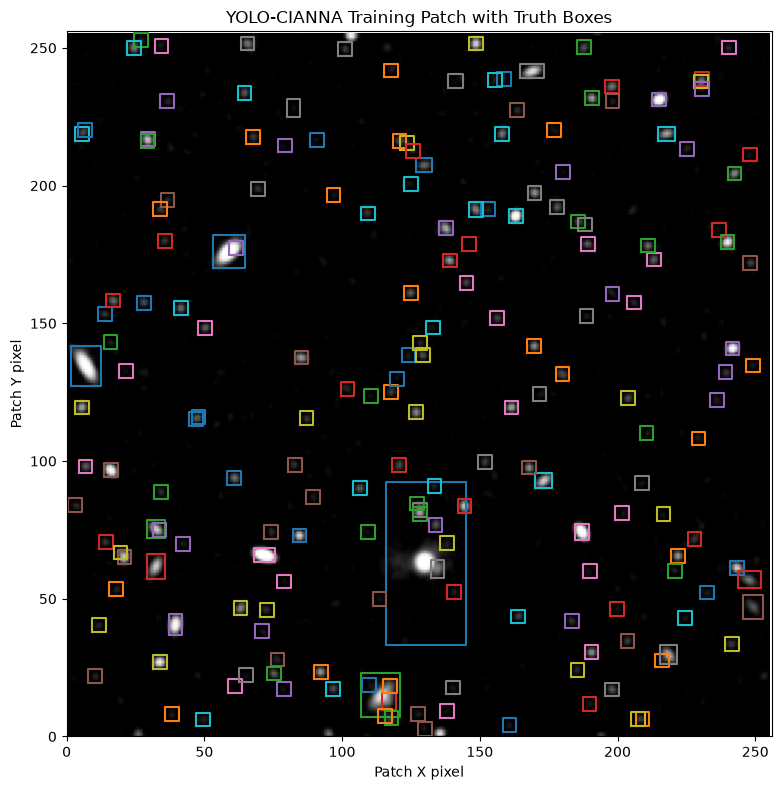

Number of labelled sources: 195


In [16]:
# Display the actual machine-learning input patch
plt.figure(
    figsize=(8, 8)
)

plt.imshow(
    patch,
    origin="lower",
    cmap="gray"
)

# Draw the ground-truth bounding box for every source
for _, source in patch_sources.iterrows():

    local_x = (
        source["pixel_x"]
        - global_patch_x_min
    )

    local_y = (
        source["pixel_y"]
        - global_patch_y_min
    )

    box_width = source["box_width"]
    box_height = source["box_height"]

    x_left = (
        local_x
        - box_width / 2.0
    )

    x_right = (
        local_x
        + box_width / 2.0
    )

    y_bottom = (
        local_y
        - box_height / 2.0
    )

    y_top = (
        local_y
        + box_height / 2.0
    )

    plt.plot(
        [
            x_left,
            x_right,
            x_right,
            x_left,
            x_left,
        ],
        [
            y_bottom,
            y_bottom,
            y_top,
            y_top,
            y_bottom,
        ]
    )

plt.xlabel(
    "Patch X pixel"
)

plt.ylabel(
    "Patch Y pixel"
)

plt.title(
    "YOLO-CIANNA Training Patch with Truth Boxes"
)

plt.xlim(
    0,
    image_size
)

plt.ylim(
    0,
    image_size
)

plt.tight_layout()
plt.show()

print(
    "Number of labelled sources:",
    len(patch_sources)
)

In [17]:
# Build detection targets for the current patch
patch_targets = []

for _, source in patch_sources.iterrows():

    center_x = (
        source["pixel_x"]
        - global_patch_x_min
    )

    center_y = (
        source["pixel_y"]
        - global_patch_y_min
    )

    patch_targets.append(
        {
            "x": center_x,
            "y": center_y,
            "width": source["box_width"],
            "height": source["box_height"],
            "flux": source["FLUX"],
            "bmaj": source["BMAJ"],
            "bmin": source["BMIN"],
            "pa": source["PA"],
        }
    )

patch_targets = pd.DataFrame(
    patch_targets
)

patch_targets.head()

,x,y,width,height,flux,bmaj,bmin,pa
0,130.436509,62.727441,29.073395,59.338795,0.000348,17.379,7.377,94.726
1,169.717273,141.740799,5.000000,5.000000,0.000012,0.185,0.185,291.605
2,113.913832,15.013339,14.081548,15.850144,0.000112,4.883,1.553,-51.515
3,117.009680,12.636244,5.000000,6.111285,0.000011,1.715,0.684,-68.262
4,39.491254,40.593310,5.000000,7.425128,0.000073,2.150,0.702,-79.229


In [18]:
# Define physical-parameter clipping ranges
flux_clip = (1.9e-6, 0.002)
bmaj_clip = (0.9, 60.0)
bmin_clip = (0.3, 30.0)

# Clip the physical parameters
flux_values = np.clip(
    train_catalog["apparent_flux"].to_numpy(),
    flux_clip[0],
    flux_clip[1]
)

bmaj_values = np.clip(
    train_catalog["BMAJ"].to_numpy(),
    bmaj_clip[0],
    bmaj_clip[1]
)

bmin_values = np.clip(
    train_catalog["BMIN"].to_numpy(),
    bmin_clip[0],
    bmin_clip[1]
)

# Convert positive quantities to logarithmic scale
log_flux = np.log(flux_values)
log_bmaj = np.log(bmaj_values)
log_bmin = np.log(bmin_values)

# Store normalization limits
flux_log_min = log_flux.min()
flux_log_max = log_flux.max()

bmaj_log_min = log_bmaj.min()
bmaj_log_max = log_bmaj.max()

bmin_log_min = log_bmin.min()
bmin_log_max = log_bmin.max()

# Normalize the physical quantities
train_catalog["target_flux"] = (
    (log_flux - flux_log_min)
    /
    (flux_log_max - flux_log_min)
)

train_catalog["target_bmaj"] = (
    (log_bmaj - bmaj_log_min)
    /
    (bmaj_log_max - bmaj_log_min)
)

train_catalog["target_bmin"] = (
    (log_bmin - bmin_log_min)
    /
    (bmin_log_max - bmin_log_min)
)

# Encode the position angle
pa_rad = np.deg2rad(
    train_catalog["PA"].to_numpy()
)

train_catalog["target_cos_pa"] = np.cos(pa_rad)

train_catalog["target_sin_pa"] = (
    np.sin(pa_rad) + 1.0
) / 2.0

print("Training sources:", len(train_catalog))

Training sources: 33813


In [19]:
# Define YOLO grid geometry
cell_size = 16
grid_size = image_size // cell_size

# Use the YOLO-CIANNA reference box priors
anchors = np.array(
    [
        [6.0, 6.0],
        [6.0, 6.0],
        [6.0, 6.0],
        [6.0, 6.0],
        [6.0, 6.0],
        [6.0, 6.0],
        [12.0, 9.0],
        [9.0, 12.0],
        [24.0, 24.0],
    ],
    dtype=np.float32
)

num_anchors = len(anchors)

# The network predicts 10 values per anchor
num_outputs_per_anchor = 10

print("Grid:", grid_size, "x", grid_size)
print("Anchors:", num_anchors)

Grid: 16 x 16
Anchors: 9


In [20]:
def shape_iou(width, height, anchor_width, anchor_height):
    # Calculate the intersection between two centered boxes
    intersection = (
        min(width, anchor_width)
        * min(height, anchor_height)
    )

    # Calculate the union
    union = (
        width * height
        + anchor_width * anchor_height
        - intersection
    )

    return intersection / max(union, 1e-8)


def build_yolo_target(source_table):
    # Create an empty target tensor
    target = np.zeros(
        (
            num_anchors,
            num_outputs_per_anchor,
            grid_size,
            grid_size,
        ),
        dtype=np.float32
    )

    for source in source_table:

        x = source["x"]
        y = source["y"]
        width = source["width"]
        height = source["height"]

        # Ignore sources outside the patch
        if not (
            0 <= x < image_size
            and
            0 <= y < image_size
        ):
            continue

        # Find the corresponding grid cell
        grid_x = int(x // cell_size)
        grid_y = int(y // cell_size)

        # Calculate the position inside the grid cell
        offset_x = (
            x / cell_size
            - grid_x
        )

        offset_y = (
            y / cell_size
            - grid_y
        )

        # Rank anchors according to box-shape similarity
        anchor_scores = []

        for anchor_id, anchor in enumerate(anchors):

            score = shape_iou(
                width,
                height,
                anchor[0],
                anchor[1]
            )

            anchor_scores.append(
                (
                    score,
                    anchor_id
                )
            )

        anchor_scores.sort(
            reverse=True
        )

        selected_anchor = None

        # Find the best available anchor in this grid cell
        for _, anchor_id in anchor_scores:

            if (
                target[
                    anchor_id,
                    4,
                    grid_y,
                    grid_x
                ]
                == 0
            ):
                selected_anchor = anchor_id
                break

        if selected_anchor is None:
            continue

        anchor_width = anchors[
            selected_anchor,
            0
        ]

        anchor_height = anchors[
            selected_anchor,
            1
        ]

        # Encode width and height relative to the anchor
        width_target = np.log(
            max(width, 1e-6)
            / anchor_width
        )

        height_target = np.log(
            max(height, 1e-6)
            / anchor_height
        )

        target[
            selected_anchor,
            :,
            grid_y,
            grid_x
        ] = np.array(
            [
                offset_x,
                offset_y,
                width_target,
                height_target,
                1.0,
                source["flux"],
                source["bmaj"],
                source["bmin"],
                source["cos_pa"],
                source["sin_pa"],
            ],
            dtype=np.float32
        )

    return target

In [21]:
class SDC1YoloDataset(Dataset):

    def __init__(
        self,
        number_of_samples=1600,
        augment=True,
        noise_probability=0.05,
        seed=None
    ):

        self.number_of_samples = number_of_samples
        self.augment = augment
        self.noise_probability = noise_probability

        self.rng = np.random.default_rng(
            seed
        )

    def __len__(self):
        return self.number_of_samples

    def normalize_raw_patch(self, raw_patch):
        # Clip the radio intensity
        patch = np.clip(
            raw_patch,
            min_pixel_value,
            max_pixel_value
        )

        # Scale the intensity into the 0-to-1 range
        patch = (
            patch - min_pixel_value
        ) / (
            max_pixel_value
            - min_pixel_value
        )

        # Apply the YOLO-CIANNA nonlinear compression
        patch = np.tanh(
            3.0 * patch
        )

        return patch.astype(
            np.float32
        )

    def get_noise_patch(self):
        # Define the two auxiliary noise regions
        map_size = full_image.shape[0]

        noise_width = 2000
        noise_height = 5600
        noise_offset = 250

        noise_x_min = [
            noise_offset,
            map_size
            - noise_offset
            - noise_width,
        ]

        noise_y_min = [
            int(
                (
                    map_size
                    - noise_height
                ) / 2
            ),
            int(
                (
                    map_size
                    - noise_height
                ) / 2
            ),
        ]

        region_id = self.rng.integers(
            0,
            2
        )

        local_x = self.rng.integers(
            0,
            noise_width - image_size
        )

        local_y = self.rng.integers(
            0,
            noise_height - image_size
        )

        global_x = (
            noise_x_min[region_id]
            + local_x
        )

        global_y = (
            noise_y_min[region_id]
            + local_y
        )

        raw_patch = full_image[
            global_y:
            global_y + image_size,

            global_x:
            global_x + image_size
        ]

        patch = self.normalize_raw_patch(
            raw_patch
        )

        return patch, []

    def get_source_patch(self):
        # Select a random position inside the training region
        patch_x = self.rng.integers(
            0,
            training_width - image_size
        )

        patch_y = self.rng.integers(
            0,
            training_height - image_size
        )

        patch = training_image_normalized[
            patch_y:
            patch_y + image_size,

            patch_x:
            patch_x + image_size
        ].copy()

        global_x_min = (
            train_x_min + patch_x
        )

        global_y_min = (
            train_y_min + patch_y
        )

        global_x_max = (
            global_x_min + image_size
        )

        global_y_max = (
            global_y_min + image_size
        )

        source_records = []

        for _, source in train_catalog.iterrows():

            half_width = (
                source["box_width"]
                / 2.0
            )

            half_height = (
                source["box_height"]
                / 2.0
            )

            source_x = source["pixel_x"]
            source_y = source["pixel_y"]

            # Keep only boxes fully contained inside the patch
            if not (
                source_x - half_width
                > global_x_min
                and
                source_x + half_width
                < global_x_max
                and
                source_y - half_height
                > global_y_min
                and
                source_y + half_height
                < global_y_max
            ):
                continue

            source_records.append(
                {
                    "x":
                        source_x
                        - global_x_min,

                    "y":
                        source_y
                        - global_y_min,

                    "width":
                        source["box_width"],

                    "height":
                        source["box_height"],

                    "flux":
                        source["target_flux"],

                    "bmaj":
                        source["target_bmaj"],

                    "bmin":
                        source["target_bmin"],

                    "cos_pa":
                        source["target_cos_pa"],

                    "sin_pa":
                        source["target_sin_pa"],
                }
            )

        return patch, source_records

    def augment_patch(
        self,
        patch,
        sources
    ):
        # Randomly rotate the patch by 90 degrees
        rotation_random = self.rng.random()

        rotation = 0

        if rotation_random < 0.33:
            rotation = 1

        elif rotation_random < 0.66:
            rotation = -1

        if rotation != 0:

            patch = np.rot90(
                patch,
                k=rotation
            ).copy()

            for source in sources:

                old_x = source["x"]
                old_y = source["y"]

                old_width = source["width"]
                old_height = source["height"]

                if rotation == 1:

                    source["x"] = old_y

                    source["y"] = (
                        image_size
                        - old_x
                    )

                else:

                    source["x"] = (
                        image_size
                        - old_y
                    )

                    source["y"] = old_x

                source["width"] = old_height
                source["height"] = old_width

                cos_pa = source["cos_pa"]

                sin_pa = (
                    source["sin_pa"]
                    * 2.0
                    - 1.0
                )

                if rotation == 1:
                    new_cos = -sin_pa
                    new_sin = cos_pa
                else:
                    new_cos = sin_pa
                    new_sin = -cos_pa

                source["cos_pa"] = new_cos

                source["sin_pa"] = (
                    new_sin + 1.0
                ) / 2.0

        # Random horizontal flip
        if self.rng.random() < 0.5:

            patch = np.flip(
                patch,
                axis=1
            ).copy()

            for source in sources:

                source["x"] = (
                    image_size
                    - source["x"]
                )

                sin_pa = (
                    source["sin_pa"]
                    * 2.0
                    - 1.0
                )

                sin_pa = -sin_pa

                source["sin_pa"] = (
                    sin_pa + 1.0
                ) / 2.0

        # Random vertical flip
        if self.rng.random() < 0.5:

            patch = np.flip(
                patch,
                axis=0
            ).copy()

            for source in sources:

                source["y"] = (
                    image_size
                    - source["y"]
                )

                sin_pa = (
                    source["sin_pa"]
                    * 2.0
                    - 1.0
                )

                sin_pa = -sin_pa

                source["sin_pa"] = (
                    sin_pa + 1.0
                ) / 2.0

        return patch, sources

    def __getitem__(self, index):

        if (
            self.augment
            and
            self.rng.random()
            < self.noise_probability
        ):

            patch, sources = (
                self.get_noise_patch()
            )

        else:

            patch, sources = (
                self.get_source_patch()
            )

        if self.augment:

            patch, sources = (
                self.augment_patch(
                    patch,
                    sources
                )
            )

        target = build_yolo_target(
            sources
        )

        # Add the channel dimension
        patch = patch[
            None,
            :,
            :
        ]

        return (
            torch.from_numpy(
                patch
            ),
            torch.from_numpy(
                target
            )
        )

In [22]:
# Create the dynamic training dataset
train_dataset = SDC1YoloDataset(
    number_of_samples=1600,
    augment=True,
    noise_probability=0.05
)

# Create a fixed validation dataset
val_dataset = SDC1YoloDataset(
    number_of_samples=100,
    augment=False,
    noise_probability=0.0,
    seed=12345
)

batch_size = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print(
    "Training batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

Training batches: 200
Validation batches: 13


In [23]:
# Load one training batch
batch_images, batch_targets = next(
    iter(train_loader)
)

print(
    "Image batch shape:",
    batch_images.shape
)

print(
    "Target batch shape:",
    batch_targets.shape
)

print(
    "Positive source targets:",
    int(
        batch_targets[
            :,
            :,
            4,
            :,
            :
        ].sum()
    )
)

Image batch shape: torch.Size([8, 1, 256, 256])
Target batch shape: torch.Size([8, 9, 10, 16, 16])
Positive source targets: 1528


In [24]:
class YoloCiannaNet(nn.Module):

    def __init__(self):

        super().__init__()

        output_channels = (
            num_anchors
            * num_outputs_per_anchor
        )

        self.backbone = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=5,
                stride=1,
                padding=2
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                32,
                16,
                kernel_size=2,
                stride=2
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                16,
                24,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                24,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                32,
                64,
                kernel_size=2,
                stride=2
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                64,
                128,
                kernel_size=1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                128,
                192,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                192,
                128,
                kernel_size=2,
                stride=2
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                128,
                192,
                kernel_size=1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                192,
                384,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                384,
                256,
                kernel_size=1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                256,
                384,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                384,
                512,
                kernel_size=2,
                stride=2
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                512,
                768,
                kernel_size=1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                768,
                1024,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.GroupNorm(
                256,
                1024
            ),

            nn.Conv2d(
                1024,
                2048,
                kernel_size=1
            ),
            nn.ReLU(inplace=True),

            nn.Dropout2d(
                p=0.25
            ),

            nn.Conv2d(
                2048,
                output_channels,
                kernel_size=1
            )
        )

    def forward(self, x):

        output = self.backbone(x)

        batch_size_current = (
            output.shape[0]
        )

        output = output.view(
            batch_size_current,
            num_anchors,
            num_outputs_per_anchor,
            grid_size,
            grid_size
        )

        return output


model = YoloCiannaNet().to(
    device
)

print(
    "Model device:",
    next(
        model.parameters()
    ).device
)

Model device: cuda:0


In [25]:
# Send one batch through the network
test_output = model(
    batch_images.to(device)
)

print(
    "Network output shape:",
    test_output.shape
)

Network output shape: torch.Size([8, 9, 10, 16, 16])


In [26]:
class YoloCiannaLoss(nn.Module):

    def __init__(self):

        super().__init__()

        self.objectness_loss = (
            nn.BCEWithLogitsLoss(
                reduction="none"
            )
        )

        self.regression_loss = (
            nn.SmoothL1Loss()
        )

    def forward(
        self,
        prediction,
        target
    ):

        object_target = target[
            :,
            :,
            4,
            :,
            :
        ]

        positive_mask = (
            object_target > 0.5
        )

        object_logits = prediction[
            :,
            :,
            4,
            :,
            :
        ]

        object_loss_raw = (
            self.objectness_loss(
                object_logits,
                object_target
            )
        )

        # Reduce the influence of the large number of empty cells
        object_weights = torch.where(
            positive_mask,
            torch.ones_like(
                object_loss_raw
            ),
            torch.full_like(
                object_loss_raw,
                0.05
            )
        )

        object_loss = (
            object_loss_raw
            * object_weights
        ).mean()

        if positive_mask.any():

            predicted_xy = torch.sigmoid(
                prediction[
                    :,
                    :,
                    0:2,
                    :,
                    :
                ]
            ).permute(
                0,
                1,
                3,
                4,
                2
            )[positive_mask]

            target_xy = target[
                :,
                :,
                0:2,
                :,
                :
            ].permute(
                0,
                1,
                3,
                4,
                2
            )[positive_mask]

            position_loss = (
                self.regression_loss(
                    predicted_xy,
                    target_xy
                )
            )

            predicted_wh = prediction[
                :,
                :,
                2:4,
                :,
                :
            ].permute(
                0,
                1,
                3,
                4,
                2
            )[positive_mask]

            target_wh = target[
                :,
                :,
                2:4,
                :,
                :
            ].permute(
                0,
                1,
                3,
                4,
                2
            )[positive_mask]

            size_loss = (
                self.regression_loss(
                    predicted_wh,
                    target_wh
                )
            )

            raw_parameters = prediction[
                :,
                :,
                5:10,
                :,
                :
            ].permute(
                0,
                1,
                3,
                4,
                2
            )[positive_mask]

            predicted_parameters = (
                torch.zeros_like(
                    raw_parameters
                )
            )

            predicted_parameters[
                :,
                0:3
            ] = torch.sigmoid(
                raw_parameters[
                    :,
                    0:3
                ]
            )

            predicted_parameters[
                :,
                3
            ] = torch.tanh(
                raw_parameters[
                    :,
                    3
                ]
            )

            predicted_parameters[
                :,
                4
            ] = torch.sigmoid(
                raw_parameters[
                    :,
                    4
                ]
            )

            target_parameters = target[
                :,
                :,
                5:10,
                :,
                :
            ].permute(
                0,
                1,
                3,
                4,
                2
            )[positive_mask]

            parameter_loss = (
                self.regression_loss(
                    predicted_parameters,
                    target_parameters
                )
            )

        else:

            zero = (
                prediction.sum()
                * 0.0
            )

            position_loss = zero
            size_loss = zero
            parameter_loss = zero

        total_loss = (
            36.0 * position_loss
            +
            0.2 * size_loss
            +
            2.0 * object_loss
            +
            5.0 * parameter_loss
        )

        return {
            "total": total_loss,
            "position": position_loss,
            "size": size_loss,
            "objectness": object_loss,
            "parameters": parameter_loss,
        }


criterion = YoloCiannaLoss()

In [27]:
# Define the optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1.5e-4
)

num_epochs = 10

history = {
    "train_loss": [],
    "val_loss": [],
}

In [ ]:
for epoch in range(num_epochs):

    model.train()

    train_loss_sum = 0.0

    for images, targets in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        targets = targets.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        predictions = model(
            images
        )

        losses = criterion(
            predictions,
            targets
        )

        losses["total"].backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=10.0
        )

        optimizer.step()

        train_loss_sum += (
            losses["total"].item()
        )

    train_loss = (
        train_loss_sum
        / len(train_loader)
    )

    model.eval()

    val_loss_sum = 0.0

    with torch.no_grad():

        for images, targets in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            targets = targets.to(
                device,
                non_blocking=True
            )

            predictions = model(
                images
            )

            losses = criterion(
                predictions,
                targets
            )

            val_loss_sum += (
                losses["total"].item()
            )

    val_loss = (
        val_loss_sum
        / len(val_loader)
    )

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch 01/10 | Train Loss: 1.8866 | Val Loss: 1.7073


In [ ]:
# Plot the training and validation loss
epochs = np.arange(
    1,
    num_epochs + 1
)

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("YOLO-CIANNA Training History")

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Save the trained model
model_path = (
    OUTPUT_DIR
    / "yolo_cianna_10epoch.pt"
)

torch.save(
    {
        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "history":
            history,

        "anchors":
            anchors,

        "flux_limits":
            (
                flux_log_min,
                flux_log_max
            ),

        "bmaj_limits":
            (
                bmaj_log_min,
                bmaj_log_max
            ),

        "bmin_limits":
            (
                bmin_log_min,
                bmin_log_max
            ),
    },
    model_path
)

print(
    "Model saved:",
    model_path
)